# Actividad 3: Taller EDA
### Entrega: 21 de septiembre

### Instrucciones: 

1. Escoge un conjunto de datos de tu interés ( https://www.kaggle.com/datasets)

2. Utilizando Pandas, realiza:

    •  Exploración de datos nulos, datos duplicados, cantidad de filas y columnas.

    •  Limpieza de datos (Pandas: dropna, fillna, replace, etc.)

    •  Filtrado y selección de datos relevantes para tu análisis

    •  Transformación de columnas, creación de variables nuevas 

    •  Agrupaciones y resúmenes (groupby) 

3. Formula al menos 5 preguntas de análisis sobre tu conjunto de datos.

4. Responde a las pregunta planteadas con una gráfica (con título, nombres en los ejes, leyendas, etc) y una breve interpretación. 

### Conclusiones del análisis

    • Presenta al menos 3 conclusiones relevantes obtenidas a partir del análisis exploratorio. 
    • Las conclusiones deben estar sustentadas en los datos y en los resultados obtenidos. 
    • Menciona patrones, tendencias, relaciones o comportamientos importantes identificados en el conjunto de datos. 
    • Evita limitarte a describir las gráficas; explica qué significan los resultados para el contexto del conjunto de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [2]:
# Cargar el archivo
df = pd.read_csv('C:/Users/julya/OneDrive/Cursos2026/BIT_DataScience/DataBases/retail_sales_dataset.csv')
df.shape

(1000, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df_strings = df.select_dtypes(include='str')
for col in df_strings.columns:
    print(f"=== Frecuencia de valores en: {col} ===")
    print(df[col].value_counts(dropna=False)) 
    print("\n" + "-"*45 + "\n")

=== Frecuencia de valores en: Date ===
Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
              ..
2023-03-02     1
2023-08-02     1
2023-04-17     1
2023-03-30     1
2023-05-28     1
Name: count, Length: 345, dtype: int64

---------------------------------------------

=== Frecuencia de valores en: Customer ID ===
Customer ID
CUST001     1
CUST002     1
CUST003     1
CUST004     1
CUST005     1
           ..
CUST996     1
CUST997     1
CUST998     1
CUST999     1
CUST1000    1
Name: count, Length: 1000, dtype: int64

---------------------------------------------

=== Frecuencia de valores en: Gender ===
Gender
Female    510
Male      490
Name: count, dtype: int64

---------------------------------------------

=== Frecuencia de valores en: Product Category ===
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

---------------------------------------------



In [11]:
df['Date'] = pd.to_datetime(df['Date'], format= 'mixed', dayfirst= True, errors= 'coerce')

In [14]:
df['Month'] = df['Date'].dt.month_name()
df['Year'] = df['Date'].dt.year

#### Resumen de ventas por categoría de producto


In [36]:
resume_category = df.groupby('Product Category').agg(
    Total_amount = ('Total Amount', 'sum'),
    Sales_mean_by_purchase = ('Total Amount', 'mean'),
    Products_quantity = ('Quantity', 'sum'),
    Price_mean = ('Price per Unit', 'mean')
).reset_index()

resume_category

,Product Category,Total_amount,Sales_mean_by_purchase,Products_quantity,Price_mean
0,Beauty,143515,467.475570,771,184.055375
1,Clothing,155580,443.247863,894,174.287749
2,Electronics,156905,458.786550,849,181.900585


#### Resumen de clientes por edad

In [48]:
df['Age_Group'] = pd.cut(
    df['Age'], 
    bins=[17, 30, 50, 100], 
    labels=['18-30 (Jóvenes)', '31-50 (Adultos)', '51+ (Mayores)']
)

resume_age_group = df.groupby('Age_Group').agg(
    Transactions=('Transaction ID', 'count'),
    Total_amount=('Total Amount', 'sum'),
    Sales_mean_by_purchase=('Total Amount', 'mean')
).reset_index()

resume_age_group

,Age_Group,Transactions,Total_amount,Sales_mean_by_purchase
0,18-30 (Jóvenes),273,132945,486.978022
1,31-50 (Adultos),414,189745,458.321256
2,51+ (Mayores),313,133310,425.910543


#### Resumen de clientes por género y categoría de producto

In [50]:
resume_gender = df.groupby(['Product Category', 'Gender']).agg(
    Transactions=('Transaction ID', 'count'),
    Total_amount=('Total Amount', 'sum'),
    Sales_mean_by_purchase=('Total Amount', 'mean')
).reset_index()

resume_gender

,Product Category,Gender,Transactions,Total_amount,Sales_mean_by_purchase
0,Beauty,Female,166,74830,450.783133
1,Beauty,Male,141,68685,487.127660
2,Clothing,Female,174,81275,467.097701
3,Clothing,Male,177,74305,419.802260
4,Electronics,Female,170,76735,451.382353
5,Electronics,Male,172,80170,466.104651


#### Ventas por mes

In [51]:
resume_monthly = df.groupby('Month').agg(
    Total_amount = ('Total Amount', 'sum'),
    Transactions=('Transaction ID', 'count')
).reset_index()

resume_monthly

,Month,Total_amount,Transactions
0,April,33870,86
1,August,36960,94
2,December,44690,91
3,February,44060,85
4,January,36980,78
5,July,35465,72
6,June,36715,77
7,March,28990,73
8,May,53150,105
9,November,34920,78


### 5 preguntas de análisis:

#### ¿Qué categoría de producto genera el mayor volumen de ingresos y unidades vendidas?

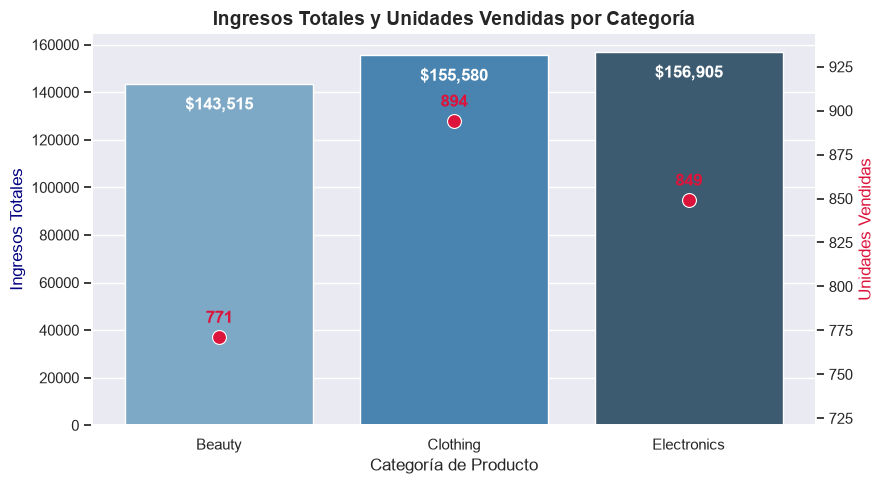

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax1 = plt.subplots(figsize=(9, 5))

# Eje 1 (Izquierdo): Gráfico de barras para Ventas Totales
sns.barplot(data=resume_category, x='Product Category', y='Total_amount', hue='Product Category', legend=False, palette='Blues_d', ax=ax1)
ax1.set_title('Ingresos Totales y Unidades Vendidas por Categoría', fontsize=14, fontweight='bold')
ax1.set_xlabel('Categoría de Producto', fontsize=12)
ax1.set_ylabel('Ingresos Totales', fontsize=12, color='navy')

# Etiquetas sobre las barras
for p in ax1.patches:
    ax1.annotate(f'${p.get_height():,.0f}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, -15), 
                 textcoords='offset points', color='white', fontweight='bold')

# Eje 2: Puntos rojos para Unidades Vendidas
ax2 = ax1.twinx()
sns.scatterplot(data=resume_category, x='Product Category', y='Products_quantity', color='crimson', s=100, zorder=5, ax=ax2)
ax2.set_ylabel('Unidades Vendidas', fontsize=12, color='crimson')
ax2.grid(False) 

# Etiquetas sobre los puntos rojos (Unidades)
for i, row in resume_category.iterrows():
    ax2.annotate(f'{int(row["Products_quantity"])}', 
                 (i, row['Products_quantity']), 
                 ha='center', va='bottom', xytext=(0, 8), 
                 textcoords='offset points', color='crimson', fontweight='bold')

# Ajuste de límites verticales en el eje derecho para que los puntos no queden pegados al borde superior
ax2.set_ylim(resume_category['Products_quantity'].min() - 50, resume_category['Products_quantity'].max() + 50)

plt.tight_layout()
plt.show()

La categoría Electronics genera la mayor cantidad de ingresos totales. Sin embargo, Clothing es la categoría que mueve más inventario físico con 894 unidades vendidas (superando las 849 de Electronics y las 771 de Beauty). 

Aunque Electronics y Clothing generan ingresos casi idénticos, Electronics lo logra vendiendo 45 unidades menos, lo que indica que sus productos tienen un precio promedio por unidad más alto.

Beauty registra los valores más bajos en ambas métricas. 

#### ¿Cómo se distribuyen las compras según los grupos de edad?

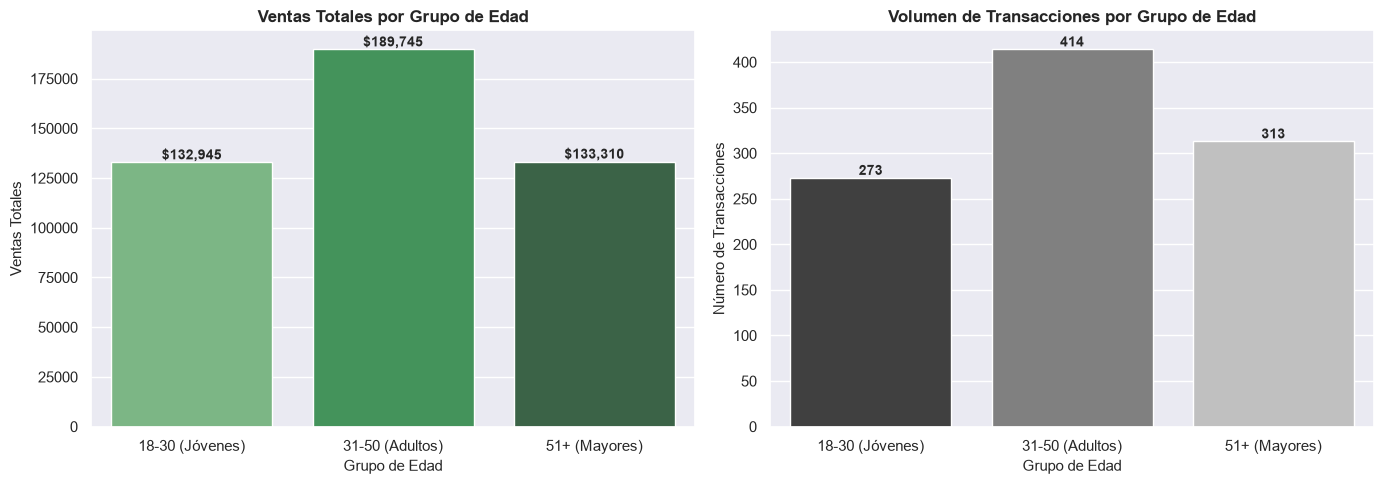

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1
sns.barplot(
    data=resume_age_group, 
    x='Age_Group', 
    y='Total_amount', 
    hue='Age_Group', 
    dodge=False, 
    legend=False, 
    palette='Greens_d', 
    ax=axes[0]
)
axes[0].set_title('Ventas Totales por Grupo de Edad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Grupo de Edad', fontsize=11)
axes[0].set_ylabel('Ventas Totales', fontsize=11)

for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():,.0f}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2
sns.barplot(
    data=resume_age_group, 
    x='Age_Group', 
    y='Transactions', 
    hue='Age_Group', 
    dodge=False, 
    legend=False, 
    palette='gray', 
    ax=axes[1]
)
axes[1].set_title('Volumen de Transacciones por Grupo de Edad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad', fontsize=11)
axes[1].set_ylabel('Número de Transacciones', fontsize=11)

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

El grupo de Adultos es el principal motor financiero del comercio, concentrando los mayores ingresos a través de 414 transacciones. Representa aproximadamente el 41.6% del volumen total de ventas, demostrando la mayor lealtad de compra.

Al comparar los segmentos de 18-30 (Jóvenes) y 51+ (Mayores), se observa una paridad en los ingresos totales. Sin embargo, la eficiencia por transacción varía significativamente:El grupo de 51+ años necesitó 313 transacciones para alcanzar su total.El grupo de 18-30 años logró una facturación equivalente realizando únicamente 273 transacciones (40 compras menos).

A partir de la relación entre ambas métricas (Total/ Transactions), se deduce que el grupo de 18-30 años posee el ticket promedio por compra más alto, seguido por los Adultos y los Mayores.

#### ¿Existe disparidad en el gasto total entre géneros según la categoría?

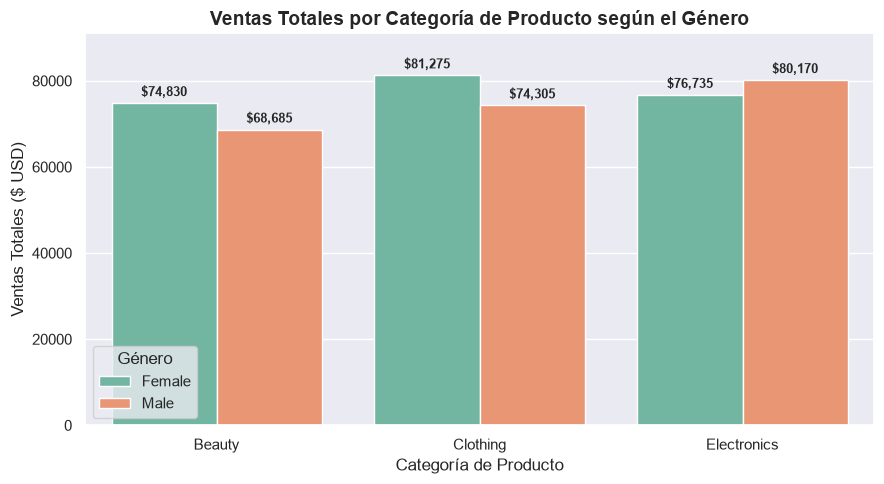

In [ ]:
plt.figure(figsize=(9, 5))

# Gráfico de barras agrupadas por Género
ax = sns.barplot(
    data=resume_gender, 
    x='Product Category', 
    y='Total_amount', 
    hue='Gender', 
    palette='Set2'
)

plt.title('Ventas Totales por Categoría de Producto según el Género', fontsize=14, fontweight='bold')
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Ventas Totales', fontsize=12)
plt.legend(title='Género', frameon=True)

# Añadir valores exactos sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'${height:,.0f}', 
            (p.get_x() + p.get_width() / 2., height), 
            ha='center', va='bottom', 
            fontsize=9.5, fontweight='bold', 
            xytext=(0, 3), textcoords='offset points'
        )

# Ajustar límite vertical para evitar que el texto se choque con el marco superior
plt.ylim(0, resume_gender['Total_amount'].max() * 1.12)

plt.tight_layout()
plt.show()

No se identifican sesgos o disparidades extremas; el consumo global está bastante balanceado entre ambos géneros en todas las líneas. Sin embargo, la estrategia comercial puede aprovechar estas ligeras inclinaciones dirigiendo campañas de Clothing y Beauty con mayor foco en el público femenino, y fortaleciendo la promoción de Electronics hacia el segmento masculino.

#### ¿Existe estacionalidad o meses pico en las ventas a lo largo del año?

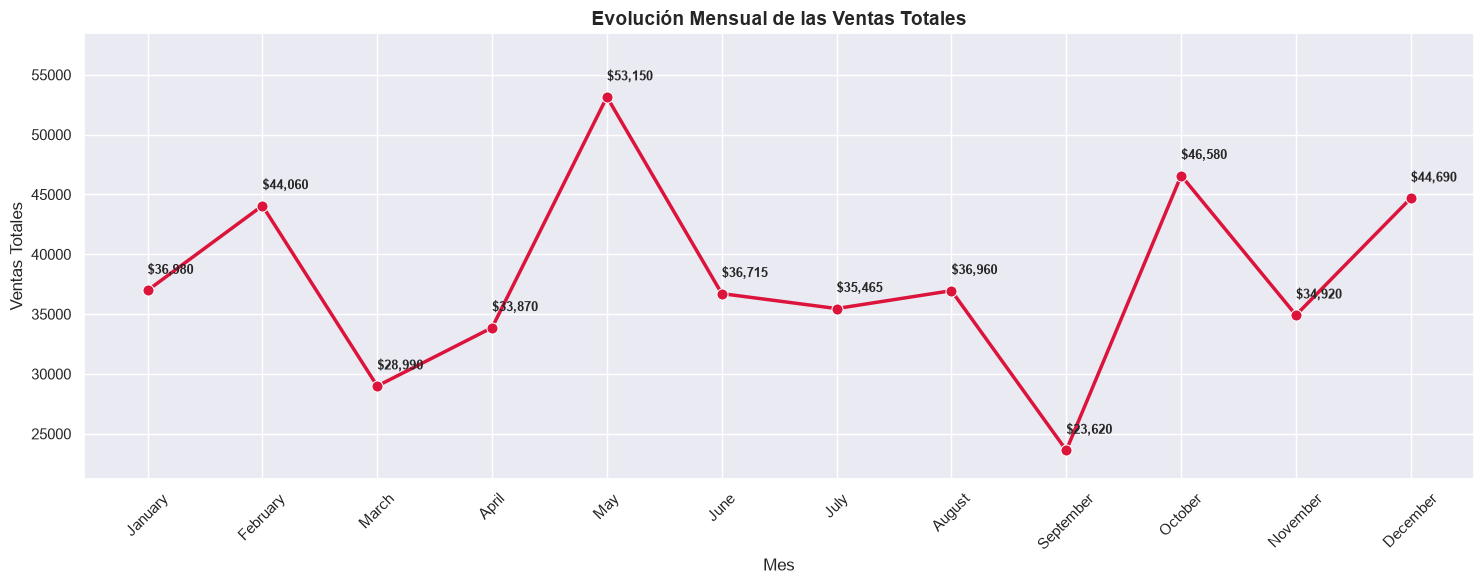

In [120]:
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']

resume_monthly['Month'] = pd.Categorical(resume_monthly['Month'], categories=orden_meses, ordered=True)
resume_monthly_sorted = resume_monthly.sort_values('Month').reset_index(drop=True)

# 2. Creación del gráfico de línea
plt.figure(figsize=(15, 6))
ax = sns.lineplot(
    data=resume_monthly_sorted, 
    x='Month', 
    y='Total_amount', 
    marker='o', 
    color='crimson', 
    linewidth=2.5, 
    markersize=8
)

plt.title('Evolución Mensual de las Ventas Totales', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Ventas Totales', fontsize=12)
plt.xticks(rotation=45)

# Añadir etiquetas con los montos exactos sobre cada punto del gráfico
for i, row in resume_monthly_sorted.iterrows():
    ax.annotate(
        f'${row["Total_amount"]:,.0f}', 
        (row['Month'], row['Total_amount']), 
        ha='left', va='bottom', 
        xytext=(0, 10), textcoords='offset points', 
        fontsize=9, fontweight='bold'
    )

# Ajustar márgenes verticales
plt.ylim(
    resume_monthly_sorted['Total_amount'].min() * 0.9, 
    resume_monthly_sorted['Total_amount'].max() * 1.1
)

plt.tight_layout()
plt.show()

El comportamiento mensual de las ventas refleja patrones claros de estacionalidad y fluctuación cíclica a lo largo del año:

Mes Pico Absoluto (Pico de Primavera): Mayo representa el punto máximo de facturación en todo el año, alcanzando 53,150. Esto responde a una fuerte estacionalidad comercial asociada a festividades clave del segundo trimestre (como el Día de la Madre).   

Picos Secundarios (Picos de Cierre de Año): Se observan rebotes significativos de consumo en Octubre (46,580), Diciembre (44,690) y Febrero (44,060). Esto demuestra que el negocio experimenta incrementos importantes de facturación hacia el último trimestre del año y durante San Valentín/comienzos de año.   

Valles / Picos Bajos (Puntos de Caída):Septiembre es el mes con el desempeño más bajo del año, registrando apenas 23,620 (un 55.5% menor que el pico de Mayo).   Marzo registra un segundo punto bajo notable con 28,990.   

Periodo de Estabilidad (Verano): Durante los meses de Junio, Julio y Agosto, las ventas se estabilizan en un rango constante alrededor de los 35,000 - 37,000 mensuales.   

#### ¿Cuál es la relación de correlación entre la edad, la cantidad de unidades y el precio por unidad?

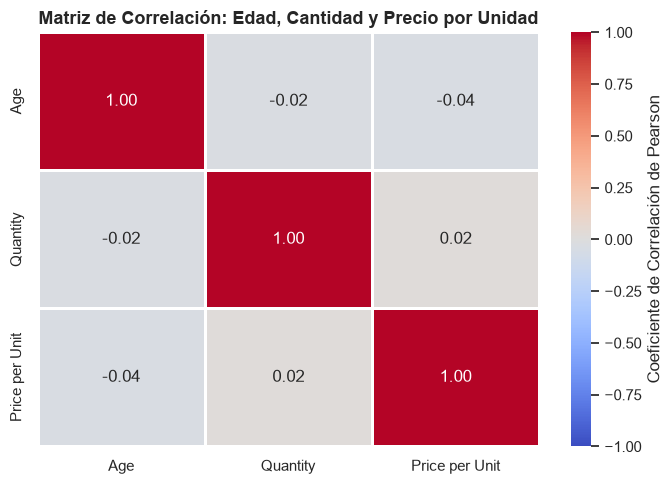

In [ ]:
# 1. Seleccionar solo las variables numéricas de interés
cols_num = ['Age', 'Quantity', 'Price per Unit'] 
corr_matrix = df[cols_num].corr()

# 2. Creación del Mapa de Calor (Heatmap)
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    vmin=-1, 
    vmax=1, 
    linewidths=1, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

plt.title('Matriz de Correlación: Edad, Cantidad y Precio por Unidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Basándonos directamente en los coeficientes de correlación de Pearson obtenidos en la matriz:

Edad (Age) vs. Cantidad (Quantity) = -0.02: 
Existe una correlación prácticamente nula. La edad del comprador no influye en la cantidad de productos que decide adquirir por transacción.   

Edad (Age) vs. Precio por Unidad (Price per Unit) = -0.04:
Tampoco existe relación lineal entre la edad y el precio del artículo comprado. Los clientes más jóvenes o mayores compran productos de rangos de precio muy similares.   

Cantidad (Quantity) vs. Precio por Unidad (Price per Unit) = 0.02:
El volumen de compra es independiente del precio unitario del producto. Un precio más elevado no desincentiva la cantidad de unidades llevadas por transacción en este conjunto de datos.   

Conclusión: Las tres variables analizadas actúan de manera totalmente independiente entre sí. 

Estrategia de Segmentación: No es recomendable intentar predecir el volumen de compra o el nivel de gasto unitario basándose únicamente en la edad del cliente. Es preferible segmentar por comportamiento de consumo, categoría de producto o canal de venta.  

#### Conclusiones del análisis:

1. Estructura de Consumo por Segmento de Edad (Frecuencia vs. Sensibilidad al Precio):

El análisis revela que el grupo de 31 a 50 años (Adultos) es el pilar financiero, concentrando 189,745 (más del 41% de la facturación) y la mayor frecuencia operativa con 414 transacciones. Sin embargo, al cruzar la facturación con el volumen transaccional, se identifica un patrón clave en el segmento de 18 a 30 años (Jóvenes): aunque realizan un 34% menos de transacciones que los adultos, registran el ticket promedio por compra más alto (487). Esto demuestra que los jóvenes tienen una menor frecuencia de visita pero una mayor disposición al gasto unitario por transacción, mientras que el volumen de los adultos está impulsado por la recurrencia.

2. Comportamiento Estacional Cíclico y Vulnerabilidad Operativa:

Existe una marcada estacionalidad en la facturación a lo largo del año, caracterizada por un pico máximo absoluto en Mayo (53,150) y picos secundarios en el último trimestre (Octubre con 46,580 y Diciembre con 44,690). Esta tendencia responde directamente a campañas comerciales de alto impacto (Día de la Madre y festividades de fin de año). No obstante, el negocio presenta un punto de vulnerabilidad crítico en Septiembre, donde las ventas caen a su mínimo histórico (23,620, un 55.5% por debajo del pico de Mayo). Este comportamiento evidencia una fuerte dependencia de las festividades del calendario y una falta de tracción comercial en los meses de transición.

3. Independencia Paramétrica y Equidad por Género en las Categorías:

El análisis de correlación de Pearson demostró que la edad, la cantidad de productos por compra y el precio unitario son variables estadísticamente independientes (coeficientes cercanos a cero, entre -0.04 y 0.02). A nivel práctico, esto significa que el valor monetario de un producto no limita la cantidad comprada ni el perfil de edad del comprador. Además, al evaluar las categorías de producto, se observa un mercado altamente equilibrado entre géneros: las mujeres lideran ligeramente en Clothing (81,275) y Beauty (74,830), mientras que los hombres muestran una ligera preferencia en Electronics (80,170), sin que existan sesgos o brechas extremas que requieran reestructurar la oferta.
